In [25]:
import os
os.environ['MEMORY_LIMIT'] = '16GB'
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import gridspec
from os.path import exists, join
from io import StringIO  
from datetime import timedelta
import math

ALGORITHMS = {
    'structural': 'Structural',
    'structural-variant': 'Splitted Structural',
    'sed': 'Sed',
    'lblint': 'Lbl-Int',
    'bib': 'Binary branch',
    'sedindex': 'Sed Index',
    'lblindex': 'Lbl-Int Index',
    'structuralindex': 'Structural Index',
}

datasets = ('dblp', 'ptb', 'python', 'sentiment', 'swissprot', 'treefam')
ALGORITHMS_ENUM_NAMES = {
    'structural': 'Structural',
    'structural-variant': 'StructuralVariant',
    'sed': 'Sed',
    'lblint': 'Lblint',
    'bib': 'Bib'
}

,Dataset,Method,SearchTime
0,3-weighted-fanout-high-fanout-60-labels-10,SED,47.0
1,3-weighted-fanout-high-fanout-60-labels-10,SEDStruct,71.0
0,3-weighted-fanout-medium-fanout-60-labels-6,SED,40.0
1,3-weighted-fanout-medium-fanout-60-labels-6,SEDStruct,49.0
0,3-weighted-fanout-small-fanout-60-labels-4,SED,52.0
1,3-weighted-fanout-small-fanout-60-labels-4,SEDStruct,74.0
0,3-weighted-fanout-low-fanout-60-labels-3,SED,63.0
1,3-weighted-fanout-low-fanout-60-labels-3,SEDStruct,80.0
0,3-weighted-fanout-verylow-fanout-60-labels-2,SED,76.0
1,3-weighted-fanout-verylow-fanout-60-labels-2,SEDStruct,81.0


(array([0.5, 1.5, 2.5, 3.5, 4.5]),
 [Text(0, 0.5, 'Labels - 10'),
  Text(0, 1.5, 'Labels - 6'),
  Text(0, 2.5, 'Labels - 4'),
  Text(0, 3.5, 'Labels - 3'),
  Text(0, 4.5, 'Labels - 2')])

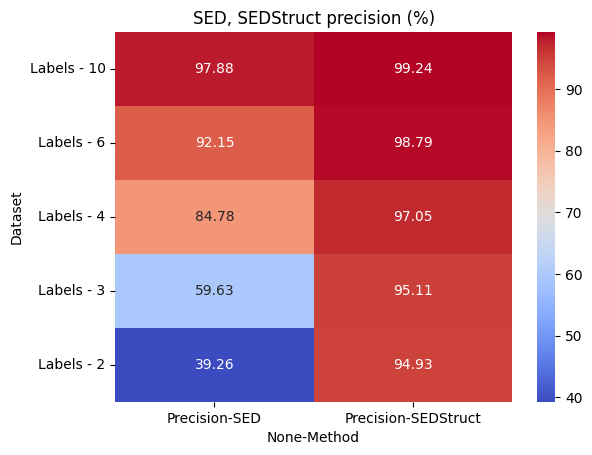

In [210]:
qdf = pd.DataFrame()

BASEPATH = 'resources/workloads/generated/'
fanout = ['high-fanout', 'medium-fanout', 'small-fanout', 'low-fanout']
datasets = [f'struct-change-3-fanout-{fo}-60-labels-20' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min

# fanout = ['high-fanout', 'medium-fanout', 'small-fanout', 'low-fanout']
# datasets = [f'2-weighted-fanout-{fo}-60-labels-10' for fo in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min



fanout = [('high-fanout', 10), ('medium-fanout', 6), ('small-fanout', 4),  ('low-fanout', 3), ('verylow-fanout', 2)]
datasets = [f'3-weighted-fanout-{fo}-60-labels-{lbls}' for fo, lbls in fanout] # structure change - change of structure wihthout relabeling 5 labels - 3 edits min


for ds in datasets:
    full_path_sed = join(BASEPATH, f'{ds}/query-sed-ukkonen.csv')
    full_path_sedstruct = join(BASEPATH, f'{ds}/query-sed-struct-ukkonen.csv')
    # read second line of file
    with open(full_path_sed) as f:
        lines = f.readlines()
        reg_time = float(lines[1].strip('ms\n').split(':')[1])
    with open(full_path_sedstruct) as f:
        lines = f.readlines()
        uk_time = float(lines[1].strip('ms\n').split(':')[1])
    tdf = pd.DataFrame({
        'Dataset': [ds] * 2,
        'Method': ['SED', 'SEDStruct'],
        'SearchTime': [reg_time, uk_time]
    })
    qdf = pd.concat([qdf, tdf])

display(qdf)

[ds, *_] = datasets

start_name_index = ds.split('-').index('fanout') + 1
end_name_index = start_name_index + 1


all_sed_candidates = pd.DataFrame()
all_sedstruct_candidates = pd.DataFrame()
for ds in datasets:
    sed_candidates = pd.read_csv(join(BASEPATH, f'{ds}/Sed_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sedstruct_candidates = pd.read_csv(join(BASEPATH, f'{ds}/SEDStruct_candidates.csv'), header=None, names=['query_id', 'candidate_id'])
    sed_candidates.insert(0, 'Dataset', ds)
    sedstruct_candidates.insert(0, 'Dataset', ds)
    all_sed_candidates = pd.concat([all_sed_candidates, sed_candidates])
    all_sedstruct_candidates = pd.concat([all_sedstruct_candidates, sedstruct_candidates])
    
all_vdf = pd.DataFrame()
for ds in datasets:
    vdf = pd.read_csv(join(BASEPATH, f'{ds}/verified-all.csv'), engine="python", skipfooter=1)
    vdf.insert(0, 'Dataset', ds)
    all_vdf = pd.concat([all_vdf, vdf])
    
sed_joined = all_sed_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')
sedstruct_joined = all_sedstruct_candidates.merge(all_vdf, on=['Dataset', 'query_id', 'candidate_id'], how='inner')

# Calculate verification times for each dataset separately
for dataset in datasets:
    sed_dataset_time = sed_joined[sed_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
    sedstruct_dataset_time = sedstruct_joined[sedstruct_joined['Dataset'] == dataset]['verification_time_micro'].sum() / 1000
    
    # Update the qdf dataframe for each dataset
    qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SED'), 'VerificationTime'] = sed_dataset_time
    qdf.loc[(qdf['Dataset'] == dataset) & (qdf['Method'] == 'SEDStruct'), 'VerificationTime'] = sedstruct_dataset_time
    
# Get SED precision
sed_precision = all_sed_candidates.groupby('Dataset').size().reset_index(name='SED_Total')
sed_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SED_Passed')
sed_precision = sed_precision.merge(sed_passed, on='Dataset', how='left').fillna(0)
sed_precision['Method'] = 'SED'
sed_precision['Precision'] = (sed_precision['SED_Passed'] / sed_precision['SED_Total']) * 100

#  Get SEDStruct precision
sedstruct_precision = all_sedstruct_candidates.groupby('Dataset').size().reset_index(name='SEDStruct_Total')
sedstruct_passed = all_vdf[all_vdf['passed'] == 1].groupby('Dataset').size().reset_index(name='SEDStruct_Passed')
sedstruct_precision = sedstruct_precision.merge(sedstruct_passed, on='Dataset', how='left').fillna(0)
sedstruct_precision['Method'] = 'SEDStruct'
sedstruct_precision['Precision'] = (sedstruct_precision['SEDStruct_Passed'] / sedstruct_precision['SEDStruct_Total']) * 100


sed_precision['Dataset'] = sed_precision['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])
sedstruct_precision['Dataset'] = sedstruct_precision['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])


# Combine results
precision_df = pd.concat([
    sed_precision[['Dataset', 'Method', 'SED_Total', 'SED_Passed', 'Precision']].rename(columns={'SED_Total': 'Total', 'SED_Passed': 'Passed'}),
    sedstruct_precision[['Dataset', 'Method', 'SEDStruct_Total', 'SEDStruct_Passed', 'Precision']].rename(columns={'SEDStruct_Total': 'Total', 'SEDStruct_Passed': 'Passed'})
])

precision_df
# precision_df['Dataset'] = precision_df['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])
pdf = precision_df.pivot(index=['Dataset'], columns=['Method'], values=['Precision'])
pdf = pdf.reindex([x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index] for x in datasets])

def rename_label(short_label):
    [sn, en] = short_label.split('-')
    [label] = [l for l in datasets if l.split('-')[start_name_index] == sn and l.split('-')[end_name_index] == en]
    parts = label.split('-')
    return f'Labels - {parts[-1]}'
  
# print(rename_label('low-fanout'))

pdf.index = pdf.index.map(rename_label)

plt.title('SED, SEDStruct precision (%)')
sns.heatmap(pdf, annot=True, fmt='.2f', cmap='coolwarm')
plt.yticks(rotation=0)


In [170]:
all_df = pd.DataFrame()
for ds in datasets:
  ldf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'tree_leafs.csv'), header=None)
  sdf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'tree_sizes.csv'), header=None)
  ddf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'avg_degrees.csv'), header=None)
  nddf = pd.read_csv(join(BASEPATH, ds, 'statistics', 'degrees.csv'), header=None)
  combined_df = pd.concat([ldf, sdf, ddf, nddf], axis=1)
  combined_df.columns = ['leaf_count', 'tree_size', 'avg_degree', 'node_degree']
  combined_df['Dataset'] = ds
  
  all_df = pd.concat([all_df, combined_df], ignore_index=True)
  
all_df['leaf_percentage'] = (all_df['leaf_count'] / all_df['tree_size']) * 100
all_df
agg = all_df.groupby('Dataset').agg({'leaf_count': ['mean', 'sum', 'median', 'std'], 'tree_size': ['mean', 'sum', 'median', 'std'], 'leaf_percentage': ['mean', 'median', 'std']})

In [171]:
all_df

,leaf_count,tree_size,avg_degree,node_degree,Dataset,leaf_percentage
0,31.0,58.0,2.111111,16,3-weighted-fanout-high-fanout-60-labels-10,53.448276
1,31.0,58.0,2.111111,1,3-weighted-fanout-high-fanout-60-labels-10,53.448276
2,31.0,58.0,2.111111,2,3-weighted-fanout-high-fanout-60-labels-10,53.448276
3,30.0,58.0,2.035714,4,3-weighted-fanout-high-fanout-60-labels-10,51.724138
4,31.0,58.0,2.111111,2,3-weighted-fanout-high-fanout-60-labels-10,53.448276
...,...,...,...,...,...,...
574493,NaN,NaN,NaN,1,3-weighted-fanout-low-fanout-60-labels-2,NaN
574494,NaN,NaN,NaN,1,3-weighted-fanout-low-fanout-60-labels-2,NaN
574495,NaN,NaN,NaN,1,3-weighted-fanout-low-fanout-60-labels-2,NaN
574496,NaN,NaN,NaN,1,3-weighted-fanout-low-fanout-60-labels-2,NaN


/tmp/ipykernel_4125/3958659649.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bx = sns.boxplot(data=all_df.dropna(subset=['tree_size']), x='Dataset', y='avg_degree', palette='Set3')


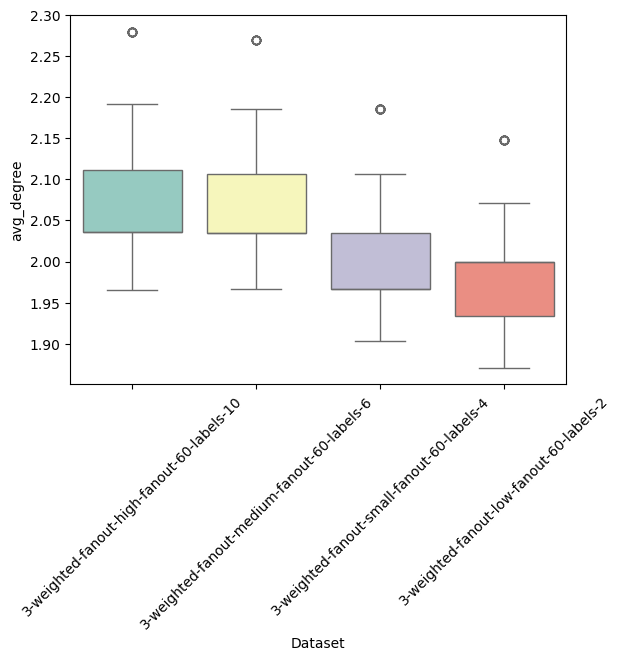

In [172]:
bx = sns.boxplot(data=all_df.dropna(subset=['tree_size']), x='Dataset', y='avg_degree', palette='Set3')
bx.tick_params(axis="x", rotation=45)

<Axes: xlabel='avg_degree', ylabel='Density'>

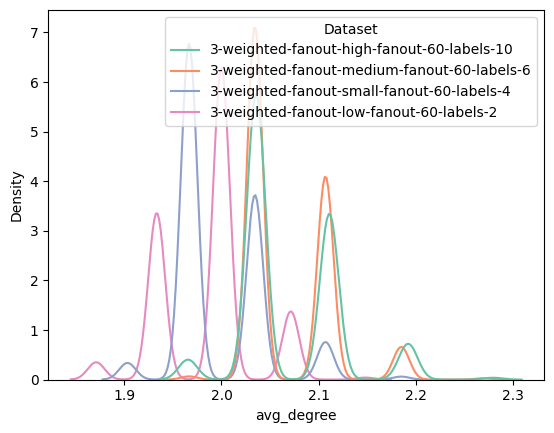

In [173]:
sns.kdeplot(data=all_df, x='avg_degree', hue='Dataset', palette='Set2')

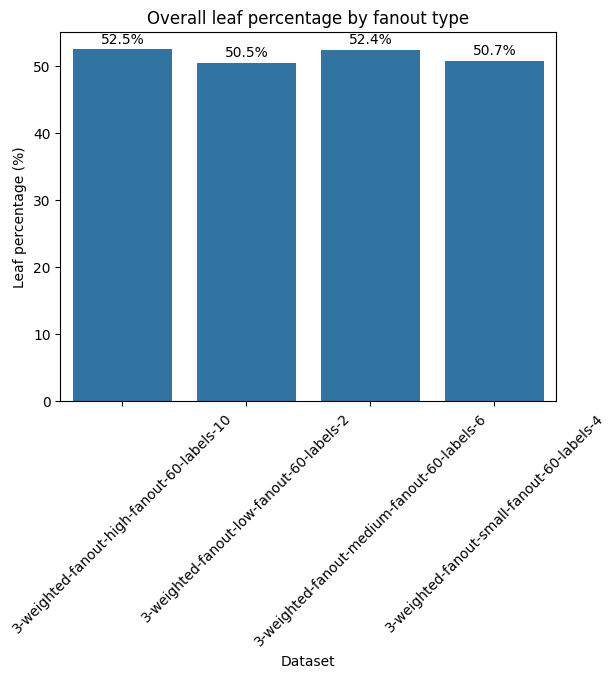

In [174]:
agg['leaf_percentage_col'] = (agg['leaf_count']['sum'] / agg['tree_size']['sum']) * 100
ax = sns.barplot(data=agg, x='Dataset', y='leaf_percentage_col')

# Annotate bars with actual values
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom')

plt.ylabel('Leaf percentage (%)')
plt.title('Overall leaf percentage by fanout type')
ax.tick_params(axis='x', rotation=45)

In [175]:
dataset_trees = dict()

for ds in datasets:
    tree_path = join(BASEPATH, ds, 'trees_sorted.bracket')
    with open(tree_path, 'r') as f:
        tree_data = f.read()
        # split by lines
        lines = tree_data.splitlines()
        # count number of nodes
        # dataset_trees[ds] = [l.split(';')[1] for l in lines]
        dataset_trees[ds] = lines
        

In [176]:
class TreeNode:
    """Basic tree node class."""

    def __init__(self, label, index: int, size: int = 0, parent: "TreeNode" = None):
        self.label = label
        self.children: list[TreeNode] = []
        self.index = index
        self.size = size
        self.parent = parent

    def add_child(self, child: "TreeNode"):
        self.children.append(child)

    def get_size(self) -> int:
        _s = len(self.children)
        for c in self.children:
            _s += c.get_size()
        return _s

    # get all nodes of the tree
    def get_all_nodes(self) -> list["TreeNode"]:
        nodes = [self]
        for c in self.children:
            nodes.extend(c.get_all_nodes())
        return nodes

    def __repr__(self, level=0):
        # ret = "\t" * level + repr(self.label) + "\n"
        ret = r"{" + str(self.label)
        for child in self.children:
            ret += child.__repr__(level + 1)
        return ret + r"}"

    def __str__(self):
        return self.__repr__()
      
    @staticmethod
    def parse_tree(s: str) -> "TreeNode":
        """Parse a tree from a bracket notation string."""
        stack = []
        current_node = None
        index = 0

        i = 0
        while i < len(s):
            char = s[i]
            if char == "{":
                # Start a new node
                if current_node is not None:
                    stack.append(current_node)
                
                # Extract label after the opening bracket
                i += 1
                label_start = i
                while i < len(s) and s[i] not in "{}":
                    i += 1
                label = s[label_start:i]
                
                index += 1
                current_node = TreeNode(label=label, index=index)
            elif char == "}":
                # End the current node
                if stack:
                    parent_node = stack.pop()
                    parent_node.add_child(current_node)
                    current_node.parent = parent_node
                    current_node = parent_node
                i += 1
            else:
                # This shouldn't happen with proper bracket notation
                i += 1

        return current_node  # Root node

In [177]:
from concurrent.futures import ProcessPoolExecutor

dataset_tree_nodes = dict()
for ds in datasets:
    tree_lines = dataset_trees[ds]
    nodes = []
    with ProcessPoolExecutor() as executor:
        for parsed_tree in executor.map(TreeNode.parse_tree, tree_lines, chunksize=256):
            nodes.append(parsed_tree)
    dataset_tree_nodes[ds] = nodes
    


In [178]:
dataset_tree_nodes.keys()

dict_keys(['3-weighted-fanout-high-fanout-60-labels-10', '3-weighted-fanout-medium-fanout-60-labels-6', '3-weighted-fanout-small-fanout-60-labels-4', '3-weighted-fanout-low-fanout-60-labels-2'])

In [179]:
import math
# for each tree get some interesting statistics
def extract_tree_statistics(tree: TreeNode) -> dict:
  """Extract various statistics from a TreeNode tree."""
  
  def get_height(node: TreeNode) -> int:
    """Get the height of the tree."""
    if not node.children:
      return 0
    return 1 + max(get_height(child) for child in node.children)
  
  def get_leaf_count(node: TreeNode) -> int:
    """Count the number of leaf nodes."""
    if not node.children:
      return 1
    return sum(get_leaf_count(child) for child in node.children)
  
  def get_node_count(node: TreeNode) -> int:
    """Count the total number of nodes."""
    return 1 + sum(get_node_count(child) for child in node.children)
  
  def get_degrees(node: TreeNode, depth: int = 1) -> list[tuple[int, int]]:
    """Get the degree (number of children) of each node."""
    degrees = [(len(node.children), depth)]
    for child in node.children:
      degrees.extend(get_degrees(child, depth + 1))
    return degrees
  
  def get_depth_distribution(node: TreeNode, depth: int = 0) -> dict:
    """Get the distribution of nodes at each depth level."""
    distribution = {depth: 1}
    for child in node.children:
      child_dist = get_depth_distribution(child, depth + 1)
      for d, count in child_dist.items():
        distribution[d] = distribution.get(d, 0) + count
    return distribution
  
  def weighted_fanout_by_depth(tree: TreeNode) -> float:
    """Fanout weighted by inverse depth.
    
    High-degree nodes near the root contribute more than deep ones.
    """
    def collect_degrees_with_depth(node: TreeNode, depth: int = 0) -> list:
        """Returns list of (degree, depth) tuples."""
        result = [(len(node.children), depth)]
        for child in node.children:
            result.extend(collect_degrees_with_depth(child, depth + 1))
        return result
    
    degree_depth_pairs = collect_degrees_with_depth(tree)
    internal_pairs = [(d, depth) for d, depth in degree_depth_pairs if d > 0]
    
    if not internal_pairs:
        return 0.0
    
    # Weight by inverse depth (root = depth 0 gets highest weight)
    max_depth = max(depth for _, depth in internal_pairs)
    
    weighted_sum = 0.0
    weight_sum = 0.0
    
    for degree, depth in internal_pairs:
        # Nodes deeper in the tree 
        weight = depth
        weighted_sum += degree * weight
        weight_sum += weight
    
    return weighted_sum / weight_sum if weight_sum > 0 else 0.0
  
  # Calculate all statistics
  height = get_height(tree)
  leaf_count = get_leaf_count(tree)
  node_count = get_node_count(tree)
  degrees_with_depth = get_degrees(tree)
  depth_dist = get_depth_distribution(tree)
  degrees = [d for d, _ in degrees_with_depth]
  
  
  non_leafs_degree_sum = sum(d for d in degrees if d > 0)
  non_leafs_count = sum(1 for d in degrees if d > 0)
  depth_weighted_fanout = weighted_fanout_by_depth(tree)
  
  sqrt_non_leafs_degree_sum = sum(math.sqrt(d) for d in degrees if d > 0)
  
  
  # Calculate derived statistics
  avg_degree = sum(degrees) / len(degrees) if degrees else 0
  max_degree = max(degrees) if degrees else 0
  min_degree = min(degrees) if degrees else 0
  branching_factor = non_leafs_degree_sum / non_leafs_count if any(d > 0 for d in degrees) else 0
  sqrt_branching_factor = math.sqrt(non_leafs_degree_sum / non_leafs_count if any(d > 0 for d in degrees) else 0)
  sqrt_degree_branching_factor = sqrt_non_leafs_degree_sum / non_leafs_count if any(d > 0 for d in degrees) else 0
  sqrt_branching = math.sqrt(non_leafs_degree_sum)
  sqrt_degree_branching = sqrt_non_leafs_degree_sum
  
  leaf_ratio = leaf_count / node_count if node_count > 0 else 0
  
  radim_ratio = 1.0 / branching_factor
  
  return {
    'internal_degrees': [d for d in degrees if d > 0],
    'height': height,
    'node_count': node_count,
    'radim_ratio': radim_ratio,
    'leaf_count': leaf_count,
    'leaf_ratio': leaf_ratio,
    'avg_degree': avg_degree,
    'max_degree': max_degree,
    'min_degree': min_degree,
    'med_degree': np.median(degrees) if degrees else 0,
    'branching_factor': branching_factor,
    'weighted_branching_factor': sum(d * d for d in degrees if d > 0) / non_leafs_count,
    'weighted_branching_shallow_factor': sum(d / depth**2 for d, depth in degrees_with_depth if d > 0) / non_leafs_count,
    'depth_weighted_branching_factor': depth_weighted_fanout,
    'sqrt_degree_branching_factor': sqrt_degree_branching_factor,
    'sqrt_branching_factor': sqrt_branching_factor,
    'sqrt_branching': sqrt_branching,
    'sqrt_degree_branching': sqrt_degree_branching,
    'depth_distribution': depth_dist,
    'width': max(depth_dist.values()) if depth_dist else 0  # Maximum nodes at any level
  }

# Test the function with first tree from first dataset
sample_tree = dataset_tree_nodes[datasets[0]][0]
sample_stats = extract_tree_statistics(sample_tree)
print("Sample tree statistics:")
for key, value in sample_stats.items():
  if key != 'depth_distribution':
    print(f"{key}: {value}")


Sample tree statistics:
internal_degrees: [16, 1, 2, 4, 2, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 2, 4, 2, 1, 1]
height: 7
node_count: 58
radim_ratio: 0.47368421052631576
leaf_count: 31
leaf_ratio: 0.5344827586206896
avg_degree: 0.9827586206896551
max_degree: 16
min_degree: 0
med_degree: 0.0
branching_factor: 2.111111111111111
weighted_branching_factor: 12.555555555555555
weighted_branching_shallow_factor: 0.7976488620139414
depth_weighted_branching_factor: 1.4179104477611941
sqrt_degree_branching_factor: 1.3232563726428836
sqrt_branching_factor: 1.4529663145135578
sqrt_branching: 7.54983443527075
sqrt_degree_branching: 35.72792206135786
width: 16


In [180]:
from concurrent.futures import ProcessPoolExecutor
# Create a comprehensive dataframe with all tree statistics
all_tree_stats = pd.DataFrame()

another_stats = pd.DataFrame()

for ds in datasets:
  trees = dataset_tree_nodes[ds]
  dataset_stats = []
  degree_stats = []
  
  for i, tree in enumerate(trees):
    stats = extract_tree_statistics(tree)
    # Add dataset and tree index information
    stats['Dataset'] = ds
    stats['tree_index'] = i
    # Remove depth_distribution as it's a dict and not suitable for dataframe
    stats.pop('depth_distribution', None)

    degree_stats.extend({ 'Dataset': ds, 'tree_index': i, 'degree': deg } for deg in stats['internal_degrees'])
    stats.pop('internal_degrees', None)
    dataset_stats.append(stats)
  
  # Convert to dataframe and concatenate
  dataset_df = pd.DataFrame(dataset_stats)
  dataset_degree_df = pd.DataFrame(degree_stats)
  all_tree_stats = pd.concat([all_tree_stats, dataset_df], ignore_index=True)
  another_stats  = pd.concat([another_stats, dataset_degree_df], ignore_index=True)
# Display the resulting dataframe
all_tree_stats.head()
another_stats.head()

,Dataset,tree_index,degree
0,3-weighted-fanout-high-fanout-60-labels-10,0,16
1,3-weighted-fanout-high-fanout-60-labels-10,0,1
2,3-weighted-fanout-high-fanout-60-labels-10,0,2
3,3-weighted-fanout-high-fanout-60-labels-10,0,4
4,3-weighted-fanout-high-fanout-60-labels-10,0,2


In [181]:
# create a summary statistics dataframe
summary_stats = []
for ds in datasets:
    ds_data = all_tree_stats[all_tree_stats['Dataset'] == ds]
    summary = {
        'Dataset': ds,
        'mean_leaf_count': ds_data['leaf_count'].mean(),
        'median_tree_size': ds_data['node_count'].median(),
        'std_avg_degree': ds_data['avg_degree'].std(),
        'mean_fanout': ds_data['branching_factor'].mean(),
        'median_fanout': ds_data['branching_factor'].median(),
        'mean_sqrt_fanout': ds_data['sqrt_branching_factor'].mean(),
        'median_sqrt_fanout': ds_data['sqrt_branching_factor'].median(),
        'std_sqrt_fanout': ds_data['sqrt_branching_factor'].std(),
        'mean_sqrt_degree_fanout': ds_data['sqrt_degree_branching_factor'].mean(),
        'median_sqrt_degree_fanout': ds_data['sqrt_degree_branching_factor'].median(),
        'std_sqrt_degree_fanout': ds_data['sqrt_degree_branching_factor'].std(),

        'mean_sqrt_degree': ds_data['sqrt_degree_branching'].mean(),
        'median_sqrt_degree': ds_data['sqrt_degree_branching'].median(),
        'std_sqrt_degree': ds_data['sqrt_degree_branching'].std(),

        'mean_sqrt_fanout_branching': ds_data['sqrt_branching'].mean(),
        'median_sqrt_fanout_branching': ds_data['sqrt_branching'].median(),
        'std_sqrt_fanout_branching': ds_data['sqrt_branching'].std(),
    }
    summary_stats.append(summary)

summary_df = pd.DataFrame(summary_stats)
summary_df['Dataset'] = summary_df['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])
summary_df

,Dataset,mean_leaf_count,median_tree_size,std_avg_degree,mean_fanout,median_fanout,mean_sqrt_fanout,median_sqrt_fanout,std_sqrt_fanout,mean_sqrt_degree_fanout,median_sqrt_degree_fanout,std_sqrt_degree_fanout,mean_sqrt_degree,median_sqrt_degree,std_sqrt_degree,mean_sqrt_fanout_branching,median_sqrt_fanout_branching,std_sqrt_fanout_branching
0,high-fanout,30.4384,58.0,2.220668e-16,2.069446,2.035714,1.438438,1.426785,0.018466,1.308494,1.298700,0.018667,36.051433,36.267220,0.430823,7.549834,7.549834,2.664802e-15
1,medium-fanout,31.4538,60.0,1.110334e-16,2.067815,2.034483,1.437903,1.426353,0.015820,1.300658,1.291497,0.016130,37.119203,37.357024,0.384172,7.681146,7.681146,8.882673e-16
2,small-fanout,30.4364,60.0,1.110334e-16,1.996781,1.966667,1.412978,1.402379,0.016546,1.282054,1.273958,0.016550,37.891101,38.122377,0.417498,7.681146,7.681146,8.882673e-16
3,low-fanout,29.7718,59.0,3.331002e-16,1.985546,2.000000,1.408991,1.414214,0.017037,1.284580,1.286729,0.017778,37.533822,37.509861,0.427853,7.615773,7.615773,8.882673e-16


In [182]:
# create a new dataframe, rename the dataset by extracting 'low-fanout', 'small-fanout', 'medium-fanout', 'high-fanout' from the dataset name
all_df = all_tree_stats.copy()
all_df['Dataset'] = all_df['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])

In [183]:
all_df

,height,node_count,radim_ratio,leaf_count,leaf_ratio,avg_degree,max_degree,min_degree,med_degree,branching_factor,weighted_branching_factor,weighted_branching_shallow_factor,depth_weighted_branching_factor,sqrt_degree_branching_factor,sqrt_branching_factor,sqrt_branching,sqrt_degree_branching,width,Dataset,tree_index
0,7,58,0.473684,31,0.534483,0.982759,16,0,0.0,2.111111,12.555556,0.797649,1.417910,1.323256,1.452966,7.549834,35.727922,16,high-fanout,0
1,8,58,0.473684,31,0.534483,0.982759,16,0,0.0,2.111111,12.407407,0.791026,1.450704,1.328674,1.452966,7.549834,35.874186,16,high-fanout,1
2,7,58,0.473684,31,0.534483,0.982759,15,0,0.0,2.111111,11.518519,0.760915,1.397260,1.333893,1.452966,7.549834,36.015119,15,high-fanout,2
3,6,58,0.491228,30,0.517241,0.982759,16,0,0.0,2.035714,12.035714,0.776925,1.338235,1.296918,1.426785,7.549834,36.313708,16,high-fanout,3
4,7,58,0.473684,31,0.534483,0.982759,15,0,0.0,2.111111,11.740741,0.769660,1.394366,1.327295,1.452966,7.549834,35.836973,15,high-fanout,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,7,59,0.517241,29,0.491525,0.983051,17,0,1.0,1.933333,11.933333,0.765560,1.348485,1.263364,1.390444,7.615773,37.900916,17,low-fanout,4995
19996,5,59,0.517241,29,0.491525,0.983051,17,0,1.0,1.933333,12.066667,0.772519,1.379310,1.258488,1.390444,7.615773,37.754651,17,low-fanout,4996
19997,8,59,0.517241,29,0.491525,0.983051,17,0,1.0,1.933333,11.933333,0.752872,1.366197,1.263364,1.390444,7.615773,37.900916,17,low-fanout,4997
19998,6,59,0.500000,30,0.508475,0.983051,16,0,0.0,2.000000,11.517241,0.774128,1.413793,1.291723,1.414214,7.615773,37.459973,17,low-fanout,4998


<Axes: xlabel='Dataset', ylabel='weighted_branching_shallow_factor'>

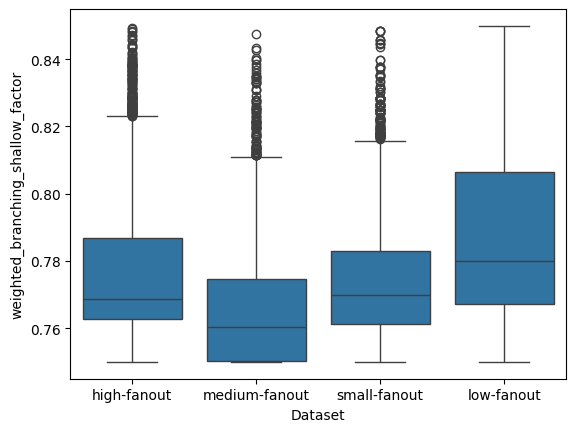

In [184]:
sns.boxplot(data=all_df, x='Dataset', y='weighted_branching_shallow_factor')
# plt.yscale('log')

<Axes: xlabel='Dataset', ylabel='depth_weighted_branching_factor'>

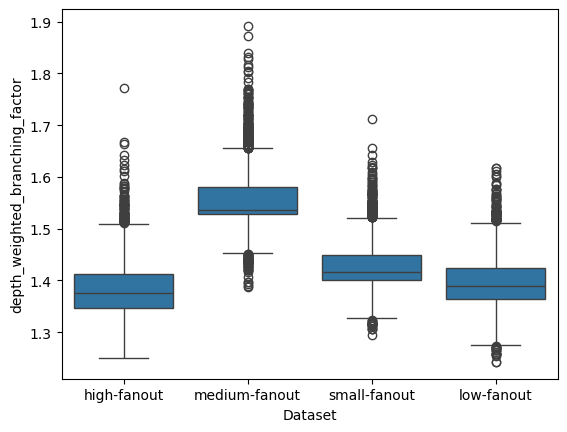

In [185]:
sns.boxplot(data=all_df, x='Dataset', y='depth_weighted_branching_factor')

<Axes: title={'center': 'Mean Square Root Fanout by Dataset'}, xlabel='Dataset', ylabel='mean_sqrt_fanout_branching'>

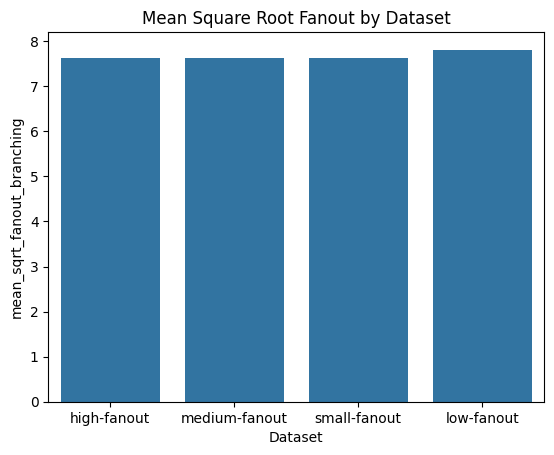

In [116]:
plt.title('Mean Square Root Fanout by Dataset')
sns.barplot(summary_df, x='Dataset', y="mean_sqrt_fanout_branching")

In [117]:
all_df

,height,node_count,radim_ratio,leaf_count,leaf_ratio,avg_degree,max_degree,min_degree,med_degree,branching_factor,weighted_branching_factor,weighted_branching_shallow_factor,depth_weighted_branching_factor,sqrt_degree_branching_factor,sqrt_branching_factor,sqrt_branching,sqrt_degree_branching,width,Dataset,tree_index
0,6,59,0.431034,34,0.576271,0.983051,12,0,0.0,2.320000,10.000000,0.775911,1.764706,1.435951,1.523155,7.615773,35.898766,22,high-fanout,0
1,6,59,0.448276,33,0.559322,0.983051,12,0,0.0,2.230769,9.384615,0.737521,1.649123,1.408878,1.493576,7.615773,36.630817,21,high-fanout,1
2,6,59,0.448276,33,0.559322,0.983051,12,0,0.0,2.230769,9.538462,0.744733,1.642857,1.403252,1.493576,7.615773,36.484552,22,high-fanout,2
3,6,59,0.448276,33,0.559322,0.983051,11,0,0.0,2.230769,8.846154,0.682575,1.721311,1.409804,1.493576,7.615773,36.654913,19,high-fanout,3
4,6,59,0.448276,33,0.559322,0.983051,12,0,0.0,2.230769,9.461538,0.744733,1.642857,1.406959,1.493576,7.615773,36.580929,22,high-fanout,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,5,62,0.442623,35,0.564516,0.983871,18,0,0.0,2.259259,15.296296,0.920854,1.568627,1.361204,1.503083,7.810250,36.752502,19,low-fanout,4995
19996,6,62,0.459016,34,0.548387,0.983871,18,0,0.0,2.178571,14.607143,0.884990,1.482143,1.336952,1.475998,7.810250,37.434664,19,low-fanout,4996
19997,5,62,0.442623,35,0.564516,0.983871,17,0,0.0,2.259259,14.185185,0.885298,1.555556,1.370270,1.503083,7.810250,36.997292,19,low-fanout,4997
19998,5,62,0.459016,34,0.548387,0.983871,17,0,0.0,2.178571,13.464286,0.849524,1.527273,1.347477,1.475998,7.810250,37.729343,18,low-fanout,4998


Text(0.5, 1.0, 'Fanout by Dataset')

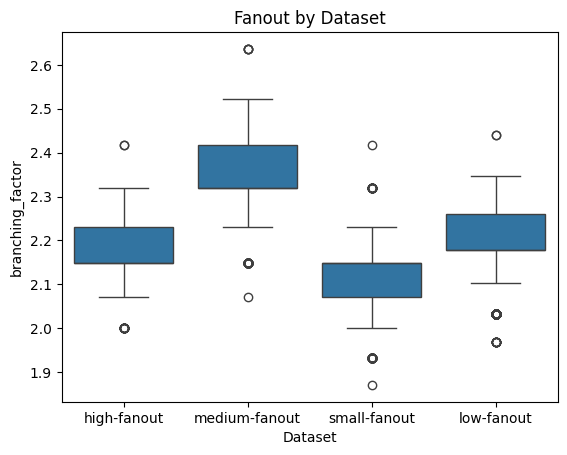

In [118]:
sns.boxplot(data=all_df, x='Dataset', y='branching_factor')
plt.title('Fanout by Dataset')

Text(0.5, 1.0, 'Width by Dataset')

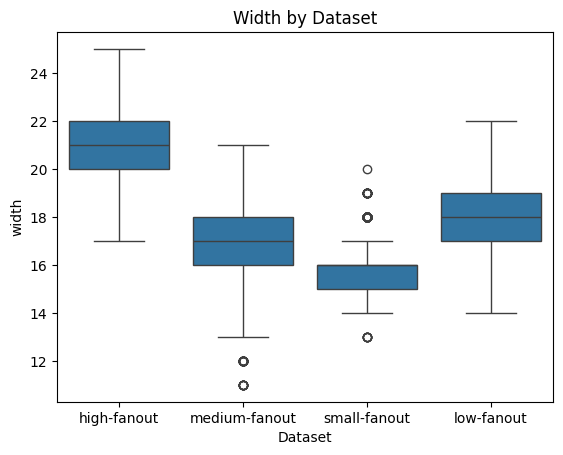

In [119]:
sns.boxplot(data=all_df, x='Dataset', y='width')
plt.title('Width by Dataset')

Text(0.5, 1.0, 'Height by Dataset')

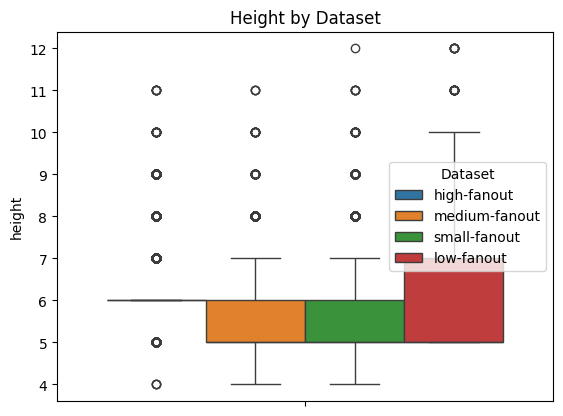

In [120]:
sns.boxplot(data=all_df, hue='Dataset', y='height')
plt.title('Height by Dataset')

In [121]:
all_df['width_height_ratio'] = all_df['width'] / all_df['height']

Text(0.5, 1.0, 'Width to Height Ratio by Dataset')

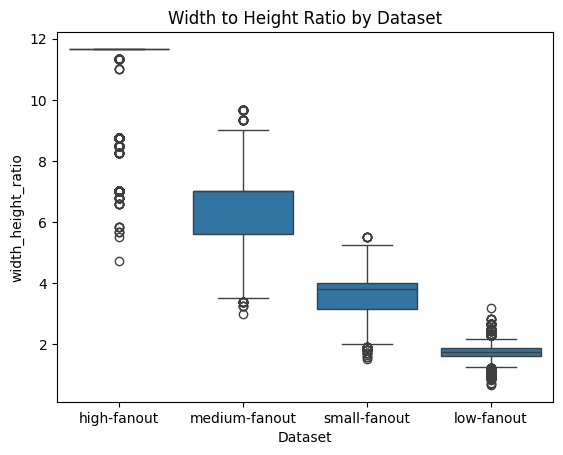

In [37]:
sns.boxplot(data=all_df, x='Dataset', y='width_height_ratio')
plt.title('Width to Height Ratio by Dataset')


Text(0.5, 1.0, 'Leaf nodes ratio per tree distribution')

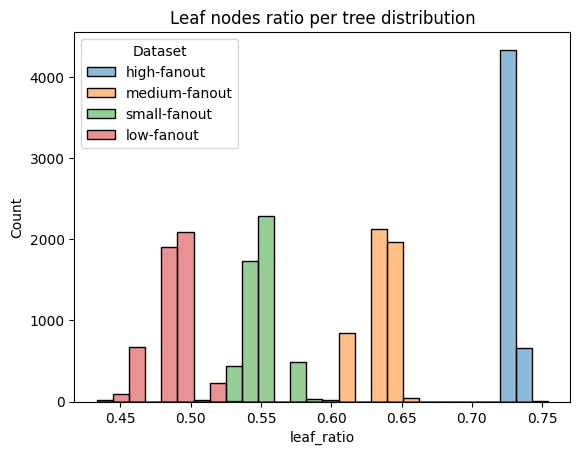

In [38]:
sns.histplot(all_df, x='leaf_ratio', hue='Dataset')
plt.title('Leaf nodes ratio per tree distribution')


Text(0.5, 1.0, 'Max node degree per tree distribution')

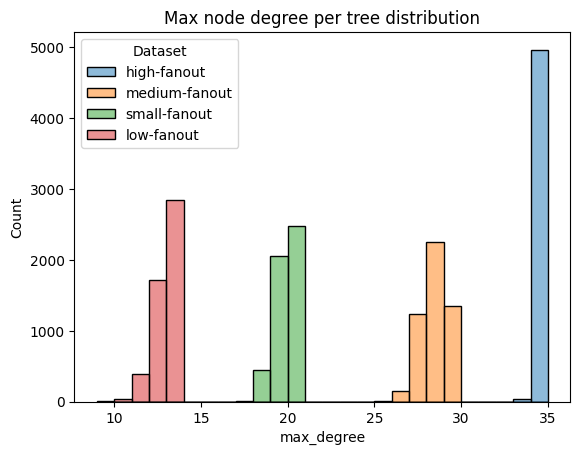

In [39]:
sns.histplot(all_df, x='max_degree', hue='Dataset')
plt.title('Max node degree per tree distribution')


Text(0.5, 1.0, 'Median node degree per tree distribution')

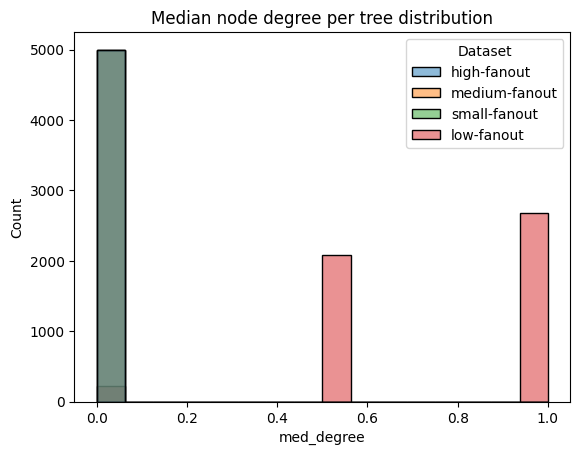

In [40]:
sns.histplot(all_df, x='med_degree', hue='Dataset')
plt.title('Median node degree per tree distribution')


<Axes: xlabel='Dataset', ylabel='degree'>

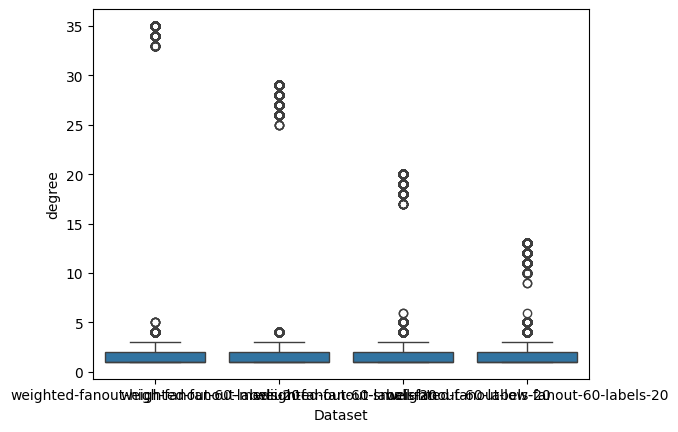

In [41]:
sns.boxplot(data=another_stats, x='Dataset', y='degree')

# Tree linearity analysis

In [42]:
def linearity_path_ratio(tree: TreeNode) -> float:
    """Ratio of average path length to maximum possible path length.
    
    Returns:
        1.0 = perfectly linear (chain)
        close to 0 = bushy tree
    """
    def get_all_path_lengths(node: TreeNode, depth: int = 0) -> list:
        if not node.children:
            return [depth]
        paths = []
        for child in node.children:
            paths.extend(get_all_path_lengths(child, depth + 1))
        return paths
    
    paths = get_all_path_lengths(tree)
    if not paths:
        return 0.0
    
    avg_path = sum(paths) / len(paths)
    max_path = max(paths)
    
    # Normalize: linear tree has avg_path ≈ max_path
    return avg_path / max_path if max_path > 0 else 0.0

In [43]:
def linearity_degree_based(tree: TreeNode) -> float:
    """Linearity based on proportion of nodes with exactly 1 child.
    
    Returns:
        1.0 = all internal nodes have 1 child (chain)
        0.0 = no nodes have exactly 1 child (bushy)
    """
    def get_degrees(node: TreeNode) -> list:
        degrees = [len(node.children)]
        for child in node.children:
            degrees.extend(get_degrees(child))
        return degrees
    
    degrees = get_degrees(tree)
    internal_degrees = [d for d in degrees if d > 0]
    
    if not internal_degrees:
        return 0.0
    
    single_child_count = sum(1 for d in internal_degrees if d == 1)
    return single_child_count, len(internal_degrees), single_child_count / len(internal_degrees)

In [44]:
def linearity_strahler(tree: TreeNode) -> float:
    """Based on Strahler number - measures tree branching complexity.
    
    Lower Strahler = more linear
    Higher Strahler = more branching
    """
    def strahler(node: TreeNode) -> int:
        if not node.children:
            return 1
        
        child_orders = sorted([strahler(c) for c in node.children], reverse=True)
        
        if len(child_orders) == 1:
            return child_orders[0]
        elif child_orders[0] == child_orders[1]:
            return child_orders[0] + 1
        else:
            return child_orders[0]
    
    s = strahler(tree)
    node_count = len(tree.get_all_nodes())
    
    # Normalize: linear chain has Strahler = 1
    # Bushy tree has higher Strahler
    return 1.0 / s if s > 0 else 0.0

In [45]:
linearity_degree_based(trees[0])

(19, 31, 0.6129032258064516)

In [46]:
datasets

['weighted-fanout-high-fanout-60-labels-20',
 'weighted-fanout-medium-fanout-60-labels-20',
 'weighted-fanout-small-fanout-60-labels-20',
 'weighted-fanout-low-fanout-60-labels-20']

In [47]:
from concurrent.futures import ProcessPoolExecutor

linearity_df = pd.DataFrame()

with ProcessPoolExecutor() as executor:
  for ds in datasets:
    trees = dataset_tree_nodes[ds]
    linearity_ratios = list(executor.map(linearity_path_ratio, trees))
    degree_linearity_ratios = list(executor.map(linearity_degree_based, trees))
    
    single_child_nodes = [r[0] for r in degree_linearity_ratios]
    internal_nodes_ratios = [r[1] for r in degree_linearity_ratios]
    degree_linearity_ratios = [r[2] for r in degree_linearity_ratios]
    
    
    strahler_linearity = list(executor.map(linearity_strahler, trees, chunksize=256))
    linearity_df = pd.concat([linearity_df, pd.DataFrame({
        'Dataset': [ds] * len(trees),
        'linearity_path_ratio': linearity_ratios,
        'linearity_degree_ratio': degree_linearity_ratios,
        'single_child_nodes': single_child_nodes,
        'internal_nodes_count': internal_nodes_ratios,
        'strahler_linearity': strahler_linearity
    })], ignore_index=True)
    # summary_df.loc[summary_df['Dataset'] == ds, 'mean_linearity_path_ratio'] = np.mean(linearity_ratios)
    # summary_df.loc[summary_df['Dataset'] == ds, 'med_linearity_path_ratio'] = np.median(linearity_ratios)
    # summary_df.loc[summary_df['Dataset'] == ds, 'min_linearity_path_ratio'] = np.min(linearity_ratios)
    
    # summary_df.loc[summary_df['Dataset'] == ds, 'mean_linearity_degree_ratio'] = np.mean(degree_linearity_ratios)
    # summary_df.loc[summary_df['Dataset'] == ds, 'med_linearity_degree_ratio'] = np.median(degree_linearity_ratios)
    # summary_df.loc[summary_df['Dataset'] == ds, 'min_linearity_degree_ratio'] = np.min(degree_linearity_ratios)
    
    # summary_df.loc[summary_df['Dataset'] == ds, 'mean_strahler_linearity'] = np.mean(strahler_linearity)
    # summary_df.loc[summary_df['Dataset'] == ds, 'med_strahler_linearity'] = np.median(strahler_linearity)
    # summary_df.loc[summary_df['Dataset'] == ds, 'min_strahler_linearity'] = np.min(strahler_linearity)
  

In [48]:
summary_df

,Dataset,mean_leaf_count,median_tree_size,std_avg_degree,mean_fanout,median_fanout,mean_sqrt_fanout,median_sqrt_fanout,std_sqrt_fanout,mean_sqrt_degree_fanout,median_sqrt_degree_fanout,std_sqrt_degree_fanout,mean_sqrt_degree,median_sqrt_degree,std_sqrt_degree,mean_sqrt_fanout_branching,median_sqrt_fanout_branching,std_sqrt_fanout_branching
0,high-fanout,44.1334,61.0,1.110334e-16,3.558856,3.529412,1.886389,1.878673,0.019782,1.504921,1.497132,0.020670,25.375979,25.451249,0.198488,7.745967,7.745967,8.882673e-16
1,medium-fanout,39.2352,62.0,1.110334e-16,2.682424,2.652174,1.637594,1.628550,0.026635,1.389455,1.390172,0.021468,31.615978,31.751475,0.613646,7.810250,7.810250,1.776535e-15
2,small-fanout,32.5772,59.0,3.331002e-16,2.197238,2.230769,1.482126,1.493576,0.023265,1.319388,1.323905,0.020264,34.845976,34.722495,0.610460,7.615773,7.615773,8.882673e-16
3,low-fanout,29.3292,60.0,1.110334e-16,1.925125,1.903226,1.387357,1.379575,0.019129,1.286761,1.286374,0.016856,39.452343,39.458558,0.623144,7.681146,7.681146,8.882673e-16


In [49]:
sns.barplot(data=summary_df, x='Dataset', y='linearity_degree_ratio')

ValueError: Could not interpret value `linearity_degree_ratio` for `y`. An entry with this name does not appear in `data`.

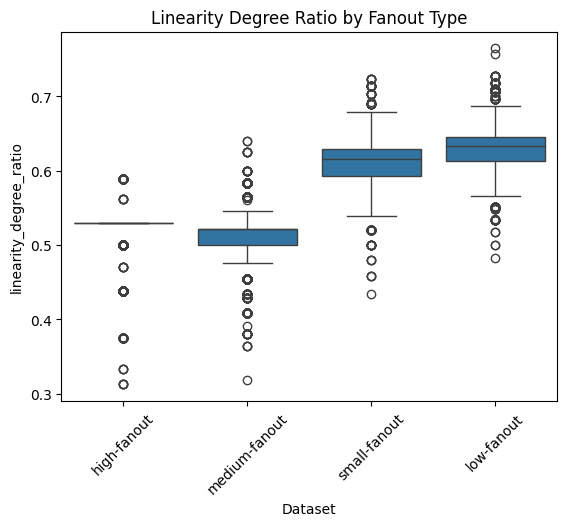

In [52]:
lin_melt_df = linearity_df.melt(id_vars='Dataset', value_vars=[
  'linearity_path_ratio',
  'linearity_degree_ratio',
  'strahler_linearity',
  'single_child_nodes',
  'internal_nodes_count',
], var_name='Linearity_Metric', value_name='Value')
lin_melt_df

renamed_df = linearity_df.copy()
renamed_df['Dataset'] = linearity_df['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])

plt.title('Linearity Degree Ratio by Fanout Type')
bx = sns.boxplot(data=renamed_df, x='Dataset', y='linearity_degree_ratio')
bx.tick_params(axis="x", rotation=45)

In [51]:
lin_melt_df = linearity_df.melt(id_vars='Dataset', value_vars=[
  'linearity_path_ratio',
  'linearity_degree_ratio',
  'strahler_linearity',
  'single_child_nodes',
  'internal_nodes_count',
], var_name='Linearity_Metric', value_name='Value')
lin_melt_df

,Dataset,Linearity_Metric,Value
0,weighted-fanout-high-fanout-60-labels-20,linearity_path_ratio,0.525926
1,weighted-fanout-high-fanout-60-labels-20,linearity_path_ratio,0.530303
2,weighted-fanout-high-fanout-60-labels-20,linearity_path_ratio,0.530303
3,weighted-fanout-high-fanout-60-labels-20,linearity_path_ratio,0.530303
4,weighted-fanout-high-fanout-60-labels-20,linearity_path_ratio,0.400000
...,...,...,...
99995,weighted-fanout-low-fanout-60-labels-20,internal_nodes_count,30.000000
99996,weighted-fanout-low-fanout-60-labels-20,internal_nodes_count,31.000000
99997,weighted-fanout-low-fanout-60-labels-20,internal_nodes_count,30.000000
99998,weighted-fanout-low-fanout-60-labels-20,internal_nodes_count,30.000000


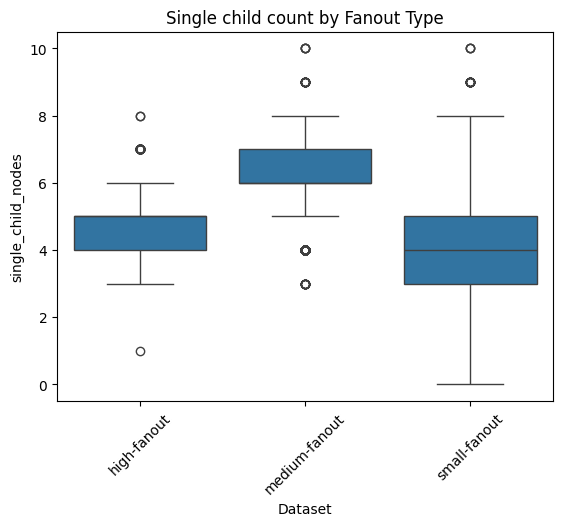

In [96]:
renamed_df = linearity_df.copy()
renamed_df['Dataset'] = linearity_df['Dataset'].apply(lambda x: x.split('-')[start_name_index] + '-' + x.split('-')[end_name_index])

plt.title('Single child count by Fanout Type')
bx = sns.boxplot(data=renamed_df, x='Dataset', y='single_child_nodes')
bx.tick_params(axis="x", rotation=45)

In [ ]:
plt.title('Internal nodes count by Fanout Type')
bx = sns.boxplot(data=renamed_df, x='Dataset', y='internal_nodes_count')
bx.tick_params(axis="x", rotation=45)

In [ ]:
datasets

In [ ]:
df = pd.DataFrame()
for ds in datasets:
    depth_distributions_path = join(BASEPATH, ds, 'statistics', 'depths.csv')
    ddf = pd.read_csv(depth_distributions_path, header=None, names=['Depth'])
    ddf['Dataset'] = ds.split('-')[start_name_index] + '-' + ds.split('-')[end_name_index]
    df = pd.concat([df, ddf], ignore_index=True)
    
df

In [ ]:
sns.displot(data=df, x='Depth', hue='Dataset', stat='density')

In [ ]:
sns.histplot(data=df, x='Depth', hue='Dataset', bins=10, multiple="fill", common_norm=True)
plt.title('Tree Depth Distribution by Fanout Type')

In [ ]:
sns.boxplot(data=df, y="Depth", hue='Dataset')

In [ ]:
def visualize_tree_d3(tree: TreeNode, output_file: str = "tree_viz.html"):
    """Generate interactive D3.js tree visualization preserving child order."""
    
    # Convert TreeNode to D3-compatible JSON
    def tree_to_dict(node: TreeNode) -> dict:
        result = {
            "name": node.label,
            "index": node.index
        }
        if node.children:
            # Important: children list order is preserved
            result["children"] = [tree_to_dict(child) for child in node.children]
        return result
    
    tree_data = tree_to_dict(tree)
    
    html_template = '''
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <style>
        .node circle {
            fill: #fff;
            stroke: steelblue;
            stroke-width: 3px;
        }
        .node text {
            font: 12px sans-serif;
        }
        .link {
            fill: none;
            stroke: #ccc;
            stroke-width: 2px;
        }
        .child-order {
            font-size: 10px;
            fill: #999;
        }
    </style>
</head>
<body>
    <svg width="1200" height="800"></svg>
    <script src="https://d3js.org/d3.v7.min.js"></script>
    <script>
        const treeData = ''' + str(tree_data).replace("'", '"') + ''';
        
        const width = 1200;
        const height = 800;
        
        const svg = d3.select("svg");
        const g = svg.append("g").attr("transform", "translate(40,0)");
        
        // Create tree layout - preserves left-to-right child order
        const tree = d3.tree().size([height, width - 160]);
        
        const root = d3.hierarchy(treeData);
        tree(root);
        
        // Draw links (edges)
        g.selectAll(".link")
            .data(root.links())
            .enter().append("path")
            .attr("class", "link")
            .attr("d", d3.linkHorizontal()
                .x(d => d.y)
                .y(d => d.x));
        
        // Draw nodes
        const node = g.selectAll(".node")
            .data(root.descendants())
            .enter().append("g")
            .attr("class", "node")
            .attr("transform", d => `translate(${d.y},${d.x})`);
        
        node.append("circle")
            .attr("r", 6);
        
        // Node labels
        node.append("text")
            .attr("dy", -10)
            .attr("text-anchor", "middle")
            .text(d => d.data.name)
            .style("font-weight", "bold");
        
        // Child order indicators (0, 1, 2, ...)
        node.each(function(d) {
            if (d.parent && d.parent.children) {
                const childIndex = d.parent.children.indexOf(d);
                d3.select(this).append("text")
                    .attr("class", "child-order")
                    .attr("dy", 15)
                    .attr("text-anchor", "middle")
                    .text(`[${childIndex}]`);
            }
        });
        
        // Add zoom
        svg.call(d3.zoom()
            .scaleExtent([0.1, 3])
            .on("zoom", (event) => {
                g.attr("transform", event.transform);
            }));
    </script>
</body>
</html>
    '''
    
    with open(output_file, 'w') as f:
        f.write(html_template)
    
    print(f"Tree visualization saved to {output_file}")
    return output_file

# Example usage
sample_tree = dataset_tree_nodes[datasets[0]][500]
visualize_tree_d3(sample_tree, "ordered_tree.html")

In [ ]:
renamed_df

In [ ]:
# Add tree index for each tree per dataset in renamed_df
renamed_df['tree_index'] = renamed_df.groupby('Dataset').cumcount()
renamed_df

In [ ]:
# Add NEW metric: structural ambiguity
def structural_ambiguity(tree: TreeNode) -> float:
    
    """Measure how ambiguous the tree structure is from traversals alone.
      
      This metric captures structural patterns that could lead to false positives
      in tree similarity algorithms like SED (String Edit Distance on trees).
      
      The intuition is that trees with many single-child nodes (chains) at 
      deeper levels create ambiguous structural signatures that are harder
      to distinguish during tree traversal comparisons.
      
      Structural ambiguity in linear/chain-like structures:

        Low-fanout → More chains (linearity ~0.45)
        Postorder of chain {a{b{c}}} = [c, b, a]
        Postorder of different structure {a{c}{b}} = [c, b, a] SAME!
        Preorder is also ambiguous without sibling information

        Preorder of {a{b}{c}} = [a, b, c]
        Preorder of {a{b{c}}} = [a, b, c] SAME!
      
      Calculation:
      1. For each node, record (depth, degree) pairs
      2. Count nodes with degree=1 (single child) at each depth level
      3. Weight deeper chains more heavily (depth * count)
      4. Normalize by total chain count
      
      Returns:
        Higher values = more structural ambiguity = potential for more false positives
        Lower values = clearer structure = better distinguishability
    
      Higher = more potential false positives in SED
    """
    def get_path_signatures(node: TreeNode, depth: int = 0) -> list:
        """Get (depth, degree) pairs for each node."""
        sig = [(depth, len(node.children))]
        for child in node.children:
            sig.extend(get_path_signatures(child, depth + 1))
        return sig
    
    sigs = get_path_signatures(tree)
    
    # Count nodes with degree 1 (chains) at each depth
    depth_chain_counts = {}
    for depth, degree in sigs:
        if degree == 1:
            depth_chain_counts[depth] = depth_chain_counts.get(depth, 0) + 1
    
    # More chains at deeper levels = higher ambiguity
    total_chains = sum(depth_chain_counts.values())
    weighted_chains = sum(depth * count for depth, count in depth_chain_counts.items())
    
    return weighted_chains / (total_chains + 1)  # Normalize

# Add to your analysis
ambiguity_data = []
for ds in datasets:
    trees = dataset_tree_nodes[ds]
    ambiguity_scores = [structural_ambiguity(tree) for tree in trees]
    
    # Create records with the transformed dataset name
    dataset_short = ds.split('-')[start_name_index] + '-' + ds.split('-')[end_name_index]
    for i, score in enumerate(ambiguity_scores):
        ambiguity_data.append({
            'Dataset': dataset_short,
            'tree_index': i,
            'structural_ambiguity': score
        })

# Create ambiguity dataframe and merge with renamed_df
ambiguity_df = pd.DataFrame(ambiguity_data)
renamed_df = renamed_df.merge(ambiguity_df, on=['Dataset', 'tree_index'], how='left')

# Expected correlation: -0.85 to -0.95 (strong negative)
# Higher ambiguity → Lower SED precision

In [ ]:
renamed_df

In [ ]:
sns.boxplot(data=renamed_df, x='Dataset', y='structural_ambiguity_y')

In [ ]:
from concurrent.futures import ProcessPoolExecutor
datasets = [
  'bolzano',
  'ptb',
  'sentiment',
  'treefam',
  'rna',
  'dblp',
  'python',
]

BASEPATH = 'resources/workloads/traditional/'

all_stats_df = pd.DataFrame()
dataset_trees: dict[str, TreeNode] = dict()
for ds in datasets:
    trees_path = join(BASEPATH, f'{ds}_sorted.bracket')
    with open(trees_path, 'r') as f:
        tree_data = f.read()
        # split by lines
        lines = tree_data.splitlines()
        with ProcessPoolExecutor() as executor:
            nodes = list(executor.map(TreeNode.parse_tree, lines, chunksize=512))
        dataset_trees[ds] = nodes
